<a href="https://colab.research.google.com/github/shreyoshi2304/Attention/blob/main/triparite_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

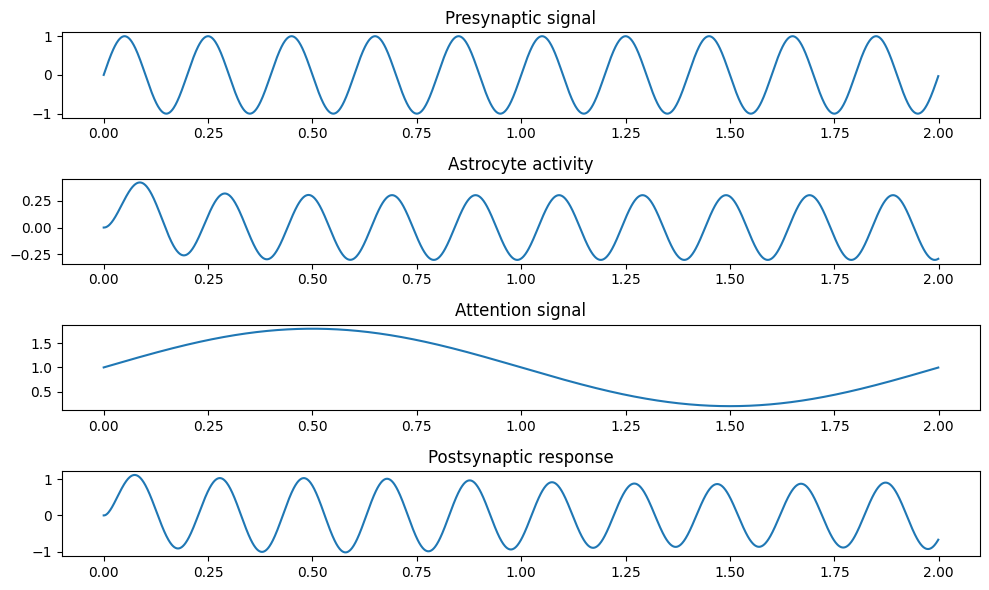

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Time
T = 2
dt = 0.001
t = np.arange(0, T, dt)

# Presynaptic activity (input signal)
pre = np.sin(2 * np.pi * 5 * t)

# Astrocyte dynamics
astro = np.zeros(len(t))
tau_astro = 0.1

# Postsynaptic neuron
post = np.zeros(len(t))
tau_post = 0.02

# Attention signal (modulates astrocyte)
attention = 1 + 0.8 * np.sin(2 * np.pi * 0.5 * t)

# Synaptic weights
w_syn = 1.0
w_astro = 0.8

for i in range(len(t) - 1):

    # Astrocyte integrates presynaptic activity
    dA = (-astro[i] + pre[i]) / tau_astro
    astro[i+1] = astro[i] + dt * dA

    # Astrocyte modulation (attention-controlled)
    astro_modulation = attention[i] * astro[i]

    # Postsynaptic input (tripartite interaction)
    syn_input = w_syn * pre[i] + w_astro * astro_modulation

    # Postsynaptic dynamics
    dV = (-post[i] + syn_input) / tau_post
    post[i+1] = post[i] + dt * dV

# Plot
plt.figure(figsize=(10,6))

plt.subplot(4,1,1)
plt.plot(t, pre)
plt.title("Presynaptic signal")

plt.subplot(4,1,2)
plt.plot(t, astro)
plt.title("Astrocyte activity")

plt.subplot(4,1,3)
plt.plot(t, attention)
plt.title("Attention signal")

plt.subplot(4,1,4)
plt.plot(t, post)
plt.title("Postsynaptic response")

plt.tight_layout()
plt.show()